# QDrift Results Analysis

This notebook analyzes evaluation and training metrics from QDrift experiments.
Produces publication-ready figures saved to `images/` for direct inclusion in LaTeX.

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Publication-quality settings
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'text.usetex': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Output directory
IMG_DIR = 'images'
os.makedirs(IMG_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


## 1. Configuration

Edit the paths below to point to your experiment directories.
Each entry maps `(env_name, seed)` to the experiment folder containing `eval.csv`, `offline_agent.csv`, and `online_agent.csv`.

In [4]:
# =============================================================================
# EDIT THIS: map each (env, seed) to its experiment directory
# =============================================================================
BASE_DIR = 'exp/qdrift'  # root of all experiments

# Auto-discover experiments: walks BASE_DIR for eval.csv files
def discover_experiments(base_dir):
    """Discover all experiments under base_dir.
    
    Expected structure: base_dir/<env_name>/<exp_hash>/eval.csv
    Returns dict: {env_name: [list of exp_dirs]}
    """
    experiments = {}
    eval_files = sorted(glob.glob(os.path.join(base_dir, '*', '*', 'eval.csv')))
    for ef in eval_files:
        exp_dir = os.path.dirname(ef)
        env_name = os.path.basename(os.path.dirname(exp_dir))
        if env_name not in experiments:
            experiments[env_name] = []
        experiments[env_name].append(exp_dir)
    return experiments

experiments = discover_experiments(BASE_DIR)

for env_name, dirs in experiments.items():
    print(f'{env_name}: {len(dirs)} seed(s)')
    for d in dirs:
        print(f'  {d}')

antmaze-medium-navigate-v0: 3 seed(s)
  exp/qdrift\antmaze-medium-navigate-v0\1
  exp/qdrift\antmaze-medium-navigate-v0\2
  exp/qdrift\antmaze-medium-navigate-v0\3


## 2. Load Data

In [6]:
def load_csv_safe(path):
    """Load a CSV file, returning None if empty or missing."""
    if not os.path.exists(path):
        return None
    try:
        df = pd.read_csv(path)
        if len(df) == 0:
            return None
        return df
    except pd.errors.EmptyDataError:
        return None

def load_experiment(exp_dir):
    """Load all CSVs from an experiment directory."""
    return {
        'eval': load_csv_safe(os.path.join(exp_dir, 'eval.csv')),
        'offline_agent': load_csv_safe(os.path.join(exp_dir, 'offline_agent.csv')),
        'online_agent': load_csv_safe(os.path.join(exp_dir, 'online_agent.csv')),
    }

# Load all experiments
all_data = {}  # {env_name: [list of dicts]}
for env_name, dirs in experiments.items():
    all_data[env_name] = [load_experiment(d) for d in dirs]

# Quick summary
for env_name, runs in all_data.items():
    eval_dfs = [r['eval'] for r in runs if r['eval'] is not None]
    if eval_dfs:
        cols = list(eval_dfs[0].columns)
        n_evals = [len(df) for df in eval_dfs]
        print(f'\n{env_name}: {len(eval_dfs)} seed(s), eval points per seed: {n_evals}')
        print(f'  Eval columns: {cols}')


antmaze-medium-navigate-v0: 3 seed(s), eval points per seed: [13, 13, 12]
  Eval columns: ['avg_gripper_contact_length', 'num_gripper_contacts', 'xy', 'prev_qpos', 'prev_qvel', 'qpos', 'qvel', 'success', 'total.timesteps', 'episode.final_reward', 'episode.return', 'episode.length', 'episode.duration', 'step']


## 3. Success Rate Learning Curves

Plots mean success rate across seeds with shaded standard deviation bands.

In [8]:
def aggregate_metric(runs, csv_key, metric, step_col='step'):
    """Aggregate a metric across seeds.
    
    Returns (steps, mean, std, individual_dfs).
    """
    dfs = [r[csv_key] for r in runs if r[csv_key] is not None]
    if not dfs or metric not in dfs[0].columns:
        return None, None, None, []
    
    # Align on common steps
    step_sets = [set(df[step_col].values) for df in dfs]
    common_steps = sorted(set.intersection(*step_sets)) if step_sets else []
    
    if not common_steps:
        # Fall back: use the longest run's steps, interpolate others
        longest = max(dfs, key=len)
        common_steps = sorted(longest[step_col].values)
    
    values = []
    for df in dfs:
        df_sorted = df.sort_values(step_col).set_index(step_col)
        # Reindex to common steps, forward-fill missing values
        reindexed = df_sorted.reindex(common_steps, method='ffill')
        if metric in reindexed.columns:
            values.append(reindexed[metric].values.astype(float))
    
    if not values:
        return None, None, None, []
    
    values = np.array(values)
    mean = np.mean(values, axis=0)
    std = np.std(values, axis=0)
    return np.array(common_steps), mean, std, dfs


def plot_learning_curve(env_name, runs, metric='success', csv_key='eval',
                        ylabel=None, title=None, ax=None, color=None,
                        label=None, show_seeds=True):
    """Plot a learning curve for a single environment."""
    steps, mean, std, dfs = aggregate_metric(runs, csv_key, metric)
    if steps is None:
        print(f'  Warning: metric "{metric}" not found for {env_name}')
        return None
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.0))
    
    c = color or '#1f77b4'
    lbl = label or 'QDrift'
    
    # Mean +/- std band
    ax.plot(steps, mean, color=c, label=lbl)
    ax.fill_between(steps, mean - std, mean + std, alpha=0.2, color=c)
    
    # Individual seeds (thin, transparent)
    if show_seeds and len(dfs) > 1:
        for df in dfs:
            df_sorted = df.sort_values('step')
            ax.plot(df_sorted['step'], df_sorted[metric].astype(float),
                    color=c, alpha=0.15, linewidth=0.8)
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel(ylabel or metric.replace('_', ' ').title())
    if title:
        ax.set_title(title)
    
    # Format x-axis with K/M suffixes
    ax.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
        )
    )
    
    return ax

Saved images\success_antmaze-medium-navigate-v0.pdf


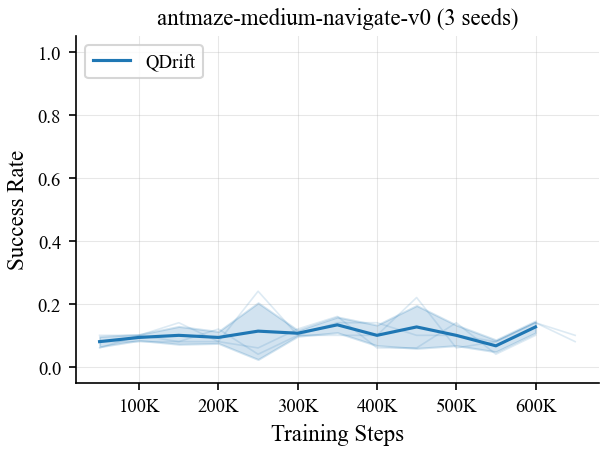

In [9]:
# Plot success rate for each environment
for env_name, runs in all_data.items():
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.0))
    
    n_seeds = len([r for r in runs if r['eval'] is not None])
    plot_learning_curve(
        env_name, runs,
        metric='success',
        ylabel='Success Rate',
        title=f'{env_name} ({n_seeds} seeds)',
        ax=ax,
    )
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='upper left')
    
    fname = f'success_{env_name}.pdf'
    fig.savefig(os.path.join(IMG_DIR, fname))
    print(f'Saved {os.path.join(IMG_DIR, fname)}')
    plt.show()

## 4. Multi-Environment Summary Plot

If multiple environments are available, display them in a single figure.

In [11]:
env_names = sorted(all_data.keys())
n_envs = len(env_names)

if n_envs > 1:
    ncols = min(3, n_envs)
    nrows = (n_envs + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, env_name in enumerate(env_names):
        n_seeds = len([r for r in all_data[env_name] if r['eval'] is not None])
        plot_learning_curve(
            env_name, all_data[env_name],
            metric='success',
            ylabel='Success Rate',
            title=f'{env_name} ({n_seeds}s)',
            ax=axes[i],
        )
        axes[i].set_ylim(-0.05, 1.05)
        axes[i].legend(loc='upper left')
    
    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.tight_layout()
    fname = 'success_all_envs.pdf'
    fig.savefig(os.path.join(IMG_DIR, fname))
    print(f'Saved {os.path.join(IMG_DIR, fname)}')
    plt.show()
else:
    print('Only one environment found; skipping multi-env summary plot.')

Only one environment found; skipping multi-env summary plot.


## 5. Final Results Table

Summary table with final success rate (mean +/- std across seeds) for each environment.
Also generates a LaTeX table that can be directly included in the paper.

In [13]:
results_rows = []

for env_name in sorted(all_data.keys()):
    runs = all_data[env_name]
    eval_dfs = [r['eval'] for r in runs if r['eval'] is not None]
    
    if not eval_dfs:
        continue
    
    # Final success rate per seed (last eval point)
    final_successes = []
    for df in eval_dfs:
        if 'success' in df.columns:
            final_successes.append(float(df['success'].iloc[-1]))
    
    if final_successes:
        mean_s = np.mean(final_successes)
        std_s = np.std(final_successes)
        results_rows.append({
            'Environment': env_name,
            'Seeds': len(final_successes),
            'Success (mean)': mean_s,
            'Success (std)': std_s,
            'Success': f'{mean_s:.3f} $\\pm$ {std_s:.3f}',
        })

results_df = pd.DataFrame(results_rows)
print('\n=== Final Results ===')
print(results_df[['Environment', 'Seeds', 'Success (mean)', 'Success (std)']].to_string(index=False))


=== Final Results ===
               Environment  Seeds  Success (mean)  Success (std)
antmaze-medium-navigate-v0      3        0.093333       0.009428


In [14]:
# Generate LaTeX table
if len(results_rows) > 0:
    latex_lines = []
    latex_lines.append(r'\begin{table}[h]')
    latex_lines.append(r'\centering')
    latex_lines.append(r'\small')
    latex_lines.append(r'\begin{tabular}{l c}')
    latex_lines.append(r'\toprule')
    latex_lines.append(r'\textbf{Environment} & \textbf{Success Rate} \\')
    latex_lines.append(r'\midrule')
    for row in results_rows:
        latex_lines.append(f'{row["Environment"]} & {row["Success"]} \\\\')
    latex_lines.append(r'\bottomrule')
    latex_lines.append(r'\end{tabular}')
    latex_lines.append(r'\caption{Preliminary QDrift results on OGBench (mean $\pm$ std over ' + str(results_rows[0]['Seeds']) + ' seeds).}')
    latex_lines.append(r'\label{tab:preliminary_results}')
    latex_lines.append(r'\end{table}')
    
    latex_table = '\n'.join(latex_lines)
    print('\n=== LaTeX Table ===')
    print(latex_table)
    
    # Save to file
    with open(os.path.join(IMG_DIR, 'results_table.tex'), 'w') as f:
        f.write(latex_table)
    print(f'\nSaved to {os.path.join(IMG_DIR, "results_table.tex")}')


=== LaTeX Table ===
\begin{table}[h]
\centering
\small
\begin{tabular}{l c}
\toprule
\textbf{Environment} & \textbf{Success Rate} \\
\midrule
antmaze-medium-navigate-v0 & 0.093 $\pm$ 0.009 \\
\bottomrule
\end{tabular}
\caption{Preliminary QDrift results on OGBench (mean $\pm$ std over 3 seeds).}
\label{tab:preliminary_results}
\end{table}

Saved to images\results_table.tex


## 6. Training Diagnostics

Critic and actor loss curves, Q-value evolution, drift magnitude over training.

In [16]:
# Training diagnostic metrics to plot
DIAGNOSTIC_METRICS = [
    ('critic/critic_loss', 'Critic Loss'),
    ('critic/q_mean', 'Mean Q-value'),
    ('actor/drift_loss', 'Drift Loss'),
    ('actor/drift_magnitude', 'Drift Magnitude $\\|V\\|$'),
    ('actor/v_attract_mag', 'Attraction $\\|V^+\\|$'),
    ('actor/v_q_mag', 'Q-gradient $\\|V^Q\\|$'),
]

for env_name, runs in all_data.items():
    # Check which metrics are available
    sample_offline = next((r['offline_agent'] for r in runs if r['offline_agent'] is not None), None)
    if sample_offline is None or len(sample_offline) < 2:
        print(f'{env_name}: no offline_agent data, skipping diagnostics.')
        continue
    
    available = [(m, label) for m, label in DIAGNOSTIC_METRICS if m in sample_offline.columns]
    if not available:
        print(f'{env_name}: no diagnostic metrics found in offline_agent.csv.')
        continue
    
    n_metrics = len(available)
    ncols = min(3, n_metrics)
    nrows = (n_metrics + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 2.8 * nrows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, (metric, label) in enumerate(available):
        # Plot offline phase
        steps_off, mean_off, std_off, _ = aggregate_metric(runs, 'offline_agent', metric)
        if steps_off is not None:
            axes[i].plot(steps_off, mean_off, color='#1f77b4', label='Offline')
            axes[i].fill_between(steps_off, mean_off - std_off, mean_off + std_off,
                                 alpha=0.2, color='#1f77b4')
        
        # Plot online phase
        steps_on, mean_on, std_on, _ = aggregate_metric(runs, 'online_agent', metric)
        if steps_on is not None and len(steps_on) > 1:
            axes[i].plot(steps_on, mean_on, color='#ff7f0e', label='Online')
            axes[i].fill_between(steps_on, mean_on - std_on, mean_on + std_on,
                                 alpha=0.2, color='#ff7f0e')
        
        axes[i].set_xlabel('Steps')
        axes[i].set_ylabel(label)
        axes[i].legend(loc='best', fontsize=7)
        axes[i].xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(
                lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
            )
        )
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'{env_name} — Training Diagnostics', fontsize=12, y=1.02)
    fig.tight_layout()
    
    fname = f'diagnostics_{env_name}.pdf'
    fig.savefig(os.path.join(IMG_DIR, fname))
    print(f'Saved {os.path.join(IMG_DIR, fname)}')
    plt.show()

antmaze-medium-navigate-v0: no diagnostic metrics found in offline_agent.csv.


## 7. Drift Magnitude Convergence

The drift magnitude $\|\mathbf{V}\|$ should decrease over training if the policy is converging.
This plot serves as an empirical proxy for convergence (see Section 3.3.1 of the paper).

C:\Users\user\AppData\Local\Temp\ipykernel_81084\3680247579.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')
C:\Users\user\AppData\Local\Temp\ipykernel_81084\3680247579.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


Saved images\drift_convergence_antmaze-medium-navigate-v0.pdf


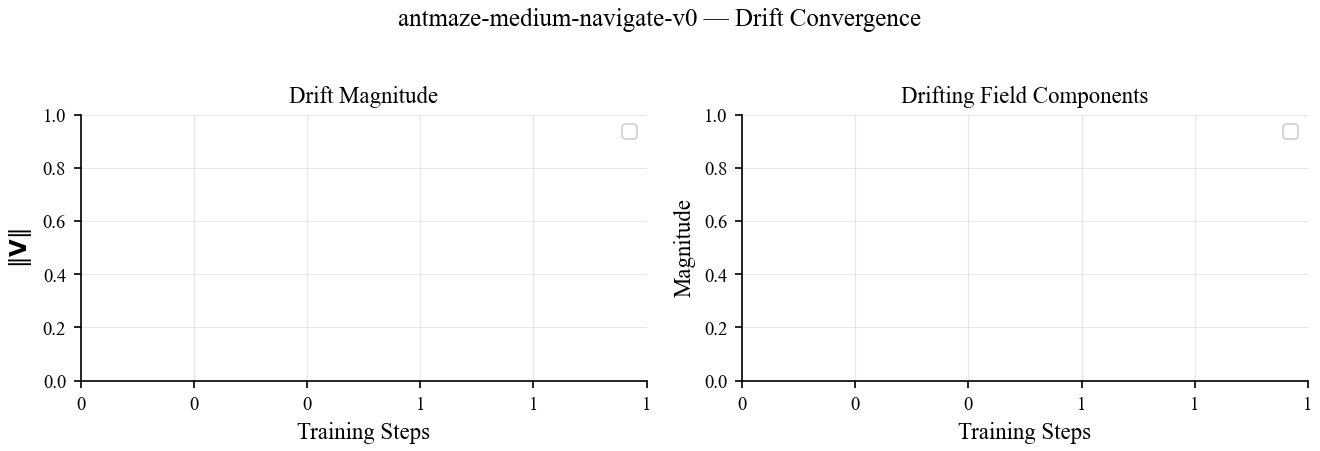

In [18]:
for env_name, runs in all_data.items():
    fig, axes = plt.subplots(1, 2, figsize=(9, 3.0))
    
    # Left: drift magnitude
    ax = axes[0]
    steps, mean, std, _ = aggregate_metric(runs, 'offline_agent', 'actor/drift_magnitude')
    if steps is not None:
        ax.plot(steps, mean, color='#2ca02c', label='Offline')
        ax.fill_between(steps, mean - std, mean + std, alpha=0.2, color='#2ca02c')
    
    steps_on, mean_on, std_on, _ = aggregate_metric(runs, 'online_agent', 'actor/drift_magnitude')
    if steps_on is not None and len(steps_on) > 1:
        ax.plot(steps_on, mean_on, color='#d62728', label='Online')
        ax.fill_between(steps_on, mean_on - std_on, mean_on + std_on, alpha=0.2, color='#d62728')
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('$\\|\\mathbf{V}\\|$')
    ax.set_title('Drift Magnitude')
    ax.legend(loc='best')
    ax.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
        )
    )
    
    # Right: component magnitudes
    ax = axes[1]
    for metric, label, color in [
        ('actor/v_attract_mag', '$\\|V^+\\|$', '#1f77b4'),
        ('actor/v_q_mag', '$\\|V^Q\\|$', '#ff7f0e'),
    ]:
        steps, mean, std, _ = aggregate_metric(runs, 'offline_agent', metric)
        if steps is not None:
            ax.plot(steps, mean, color=color, label=label)
            ax.fill_between(steps, mean - std, mean + std, alpha=0.15, color=color)
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Magnitude')
    ax.set_title('Drifting Field Components')
    ax.legend(loc='best')
    ax.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
        )
    )
    
    fig.suptitle(f'{env_name} — Drift Convergence', fontsize=12, y=1.02)
    fig.tight_layout()
    
    fname = f'drift_convergence_{env_name}.pdf'
    fig.savefig(os.path.join(IMG_DIR, fname))
    print(f'Saved {os.path.join(IMG_DIR, fname)}')
    plt.show()

## 8. Q-value Evolution

Track how the critic's Q-value estimates evolve during training.
Diverging or collapsing Q-values indicate critic instability.

C:\Users\user\AppData\Local\Temp\ipykernel_81084\1862066878.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best')


Saved images\qvalues_antmaze-medium-navigate-v0.pdf


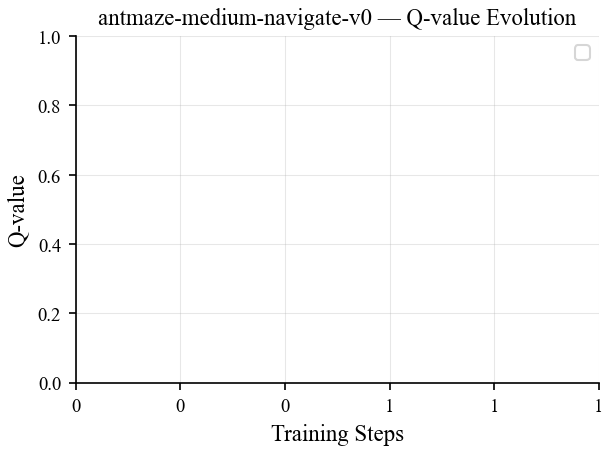

In [20]:
for env_name, runs in all_data.items():
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 3.0))
    
    for metric, label, color in [
        ('critic/q_mean', 'Mean', '#1f77b4'),
        ('critic/q_max', 'Max', '#2ca02c'),
        ('critic/q_min', 'Min', '#d62728'),
    ]:
        steps, mean, std, _ = aggregate_metric(runs, 'offline_agent', metric)
        if steps is not None:
            ax.plot(steps, mean, color=color, label=label)
            ax.fill_between(steps, mean - std, mean + std, alpha=0.15, color=color)
    
    ax.set_xlabel('Training Steps')
    ax.set_ylabel('Q-value')
    ax.set_title(f'{env_name} — Q-value Evolution')
    ax.legend(loc='best')
    ax.xaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(
            lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
        )
    )
    
    fname = f'qvalues_{env_name}.pdf'
    fig.savefig(os.path.join(IMG_DIR, fname))
    print(f'Saved {os.path.join(IMG_DIR, fname)}')
    plt.show()

## 9. Summary

Files saved in the `images/` directory:

In [22]:
saved_files = sorted(glob.glob(os.path.join(IMG_DIR, '*')))
print('Files in images/:')
for f in saved_files:
    size = os.path.getsize(f)
    print(f'  {os.path.basename(f):40s}  ({size:,} bytes)')

print('\n--- LaTeX usage examples ---')
for f in saved_files:
    name = os.path.basename(f)
    if name.endswith('.pdf'):
        print(f'\\includegraphics[width=\\columnwidth]{{images/{name}}}')
    elif name.endswith('.tex'):
        print(f'\\input{{images/{name}}}')

Files in images/:
  drift_convergence_antmaze-medium-navigate-v0.pdf  (21,873 bytes)
  qvalues_antmaze-medium-navigate-v0.pdf    (15,982 bytes)
  results_table.tex                         (332 bytes)
  success_antmaze-medium-navigate-v0.pdf    (19,030 bytes)

--- LaTeX usage examples ---
\includegraphics[width=\columnwidth]{images/drift_convergence_antmaze-medium-navigate-v0.pdf}
\includegraphics[width=\columnwidth]{images/qvalues_antmaze-medium-navigate-v0.pdf}
\input{images/results_table.tex}
\includegraphics[width=\columnwidth]{images/success_antmaze-medium-navigate-v0.pdf}
